In [1]:
import numpy as np
import covasim as cv

from strategy import Strategy
from runner import run_strategy
from policy_report import generate_policy_report


Covasim 3.1.7 (2026-02-18) — © 2020-2026 by IDM


In [2]:
sim_pars = dict(
    pop_size=50000,
    pop_infected=10,
    start_day="2020-01-01",
    end_day="2020-06-01",
    n_days=150,
)


In [3]:
strategies = []

baseline = Strategy(
    name="baseline",
    obs_pars=dict(
        p_test=0.0,
        p_seq=0.0,
        intervention_factor=1.0,
        quiet_period=7,
    ),
    trigger_list=[],
    variant_pars=dict(
        advantage=1.3,
        intro_day=50,
        reference="REF",
    )
)
strategies.append(baseline)

strategy_A = Strategy(
    name="HighSeq",
    obs_pars=dict(
        p_test=0.2,
        p_seq=0.1,
        intervention_factor=0.7,
        quiet_period=5,
    ),
    trigger_list=[
        ("sustained_increase", {"days":5}),
        ("variant_prevalence_threshold", {"threshold":0.1}),
    ],
    variant_pars=dict(
        advantage=1.3,
        intro_day=50,
        reference="REF",
    )
)
strategies.append(strategy_A)

strategy_B = Strategy(
    name="SlopeTrigger",
    obs_pars=dict(
        p_test=0.15,
        p_seq=0.05,
        intervention_factor=0.6,
        quiet_period=7,
    ),
    trigger_list=[
        ("slope_trigger", {"slope_threshold":20}),
        ("variant_growth_rate_trigger", {"growth_threshold":0.05, "window":7}),
    ],
    variant_pars=dict(
        advantage=1.3,
        intro_day=50,
        reference="REF",
    )
)
strategies.append(strategy_B)


In [4]:
results_dict = {}

for strat in strategies:
    print(f"Running strategy: {strat.name}")
    results = run_strategy(strat, sim_pars, n_runs=3)
    results_dict[strat.name] = results


Running strategy: baseline
Initializing sim with 50000 people for 152 days
Initializing sim with 50000 people for 152 days
Initializing sim with 50000 people for 152 days
Running strategy: HighSeq
Initializing sim with 50000 people for 152 days
Initializing sim with 50000 people for 152 days
Initializing sim with 50000 people for 152 days
Running strategy: SlopeTrigger
Initializing sim with 50000 people for 152 days
Initializing sim with 50000 people for 152 days
Initializing sim with 50000 people for 152 days



================ POLICY REPORT ================

=== Effectiveness metrics ===
Strategy            Cum inf    Peak inf   Time to peak
baseline            52931.0      1504.0           67.0
HighSeq             42428.0       919.0           66.0
SlopeTrigger        15348.0       367.0           48.0

=== Practicality metrics ===
Strategy         Interventions     Avg dur   Avg intensity
baseline                   0.0         0.0            0.00
HighSeq                    1.0         5.0            0.70
SlopeTrigger               3.0         8.7            0.60

=== Surveillance burden ===
Strategy               Diag         Seq       Total
baseline                0.0         0.0         0.0
HighSeq              8411.0       836.0      9247.0
SlopeTrigger         2346.0       113.0      2459.0

=== Variant detection summary ===
Strategy          Spread speed   Detect delay    Prev@det
baseline                 0.000            nan         nan
HighSeq                  0.000            nan 

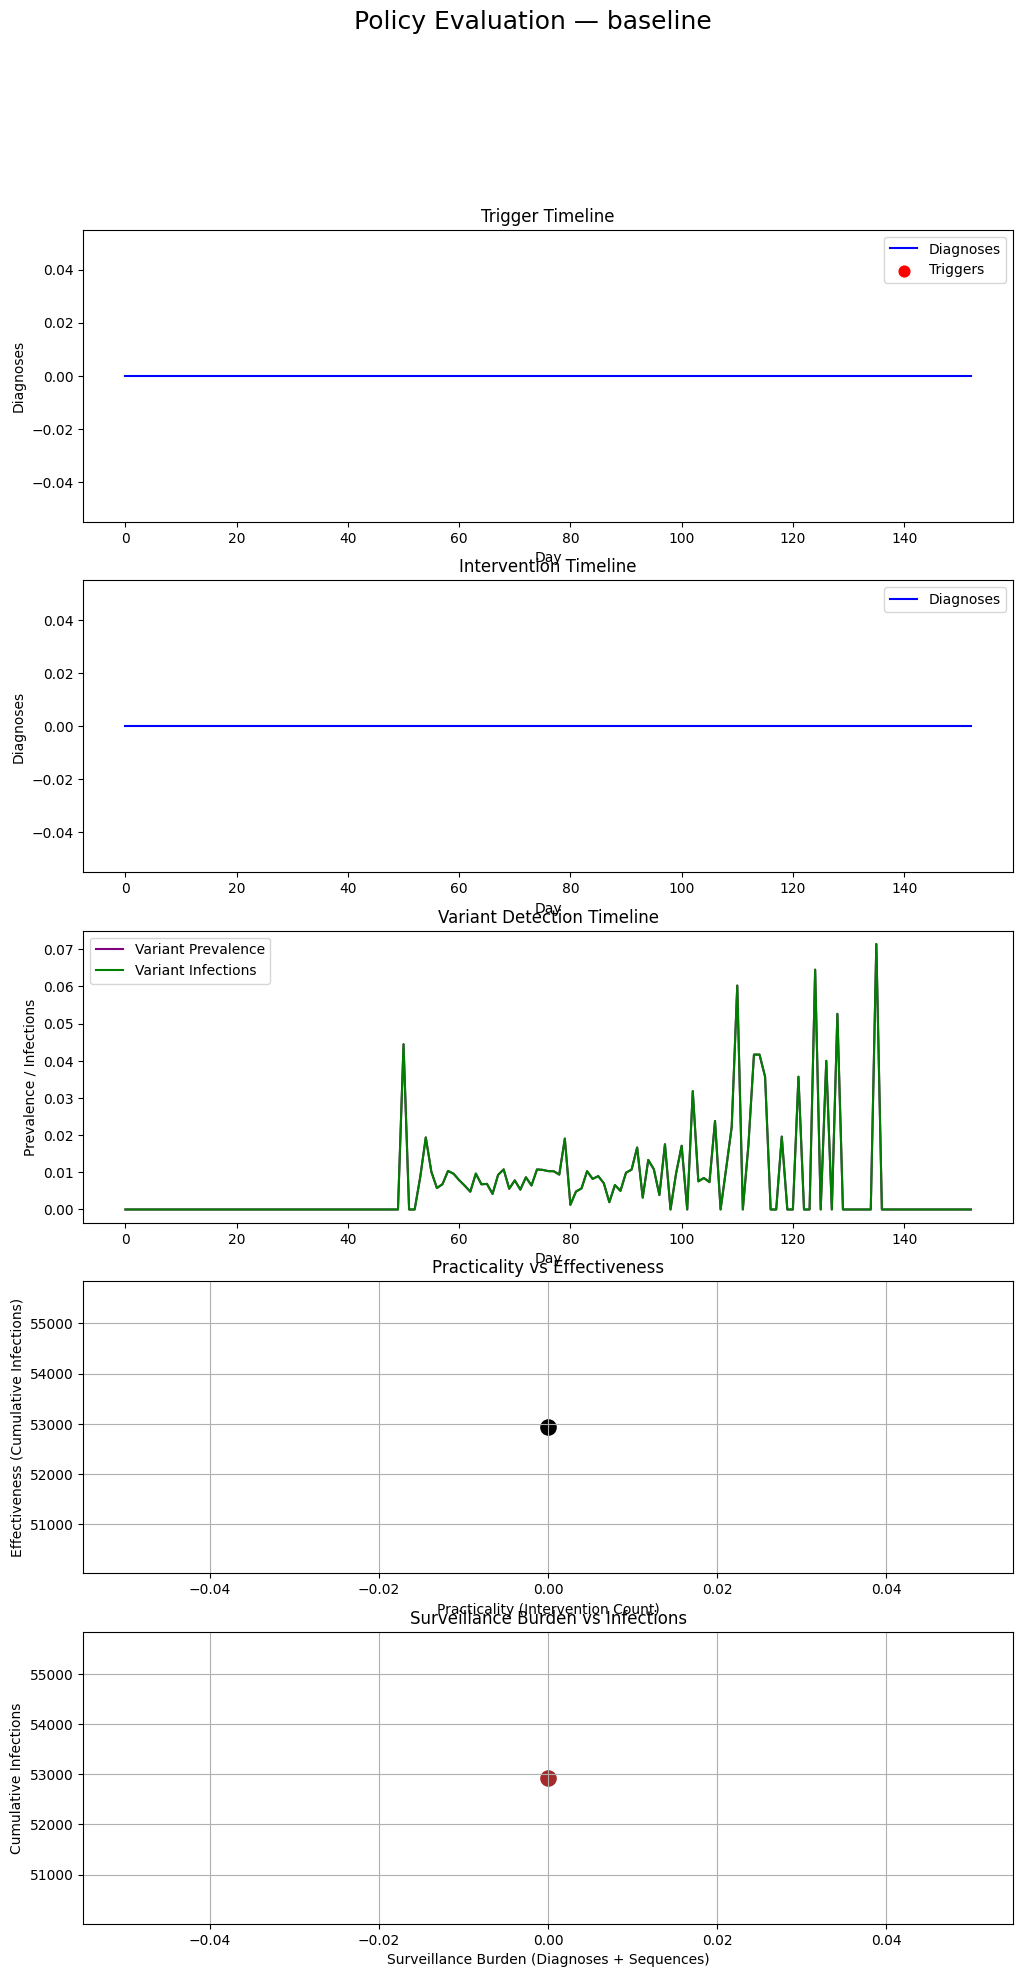

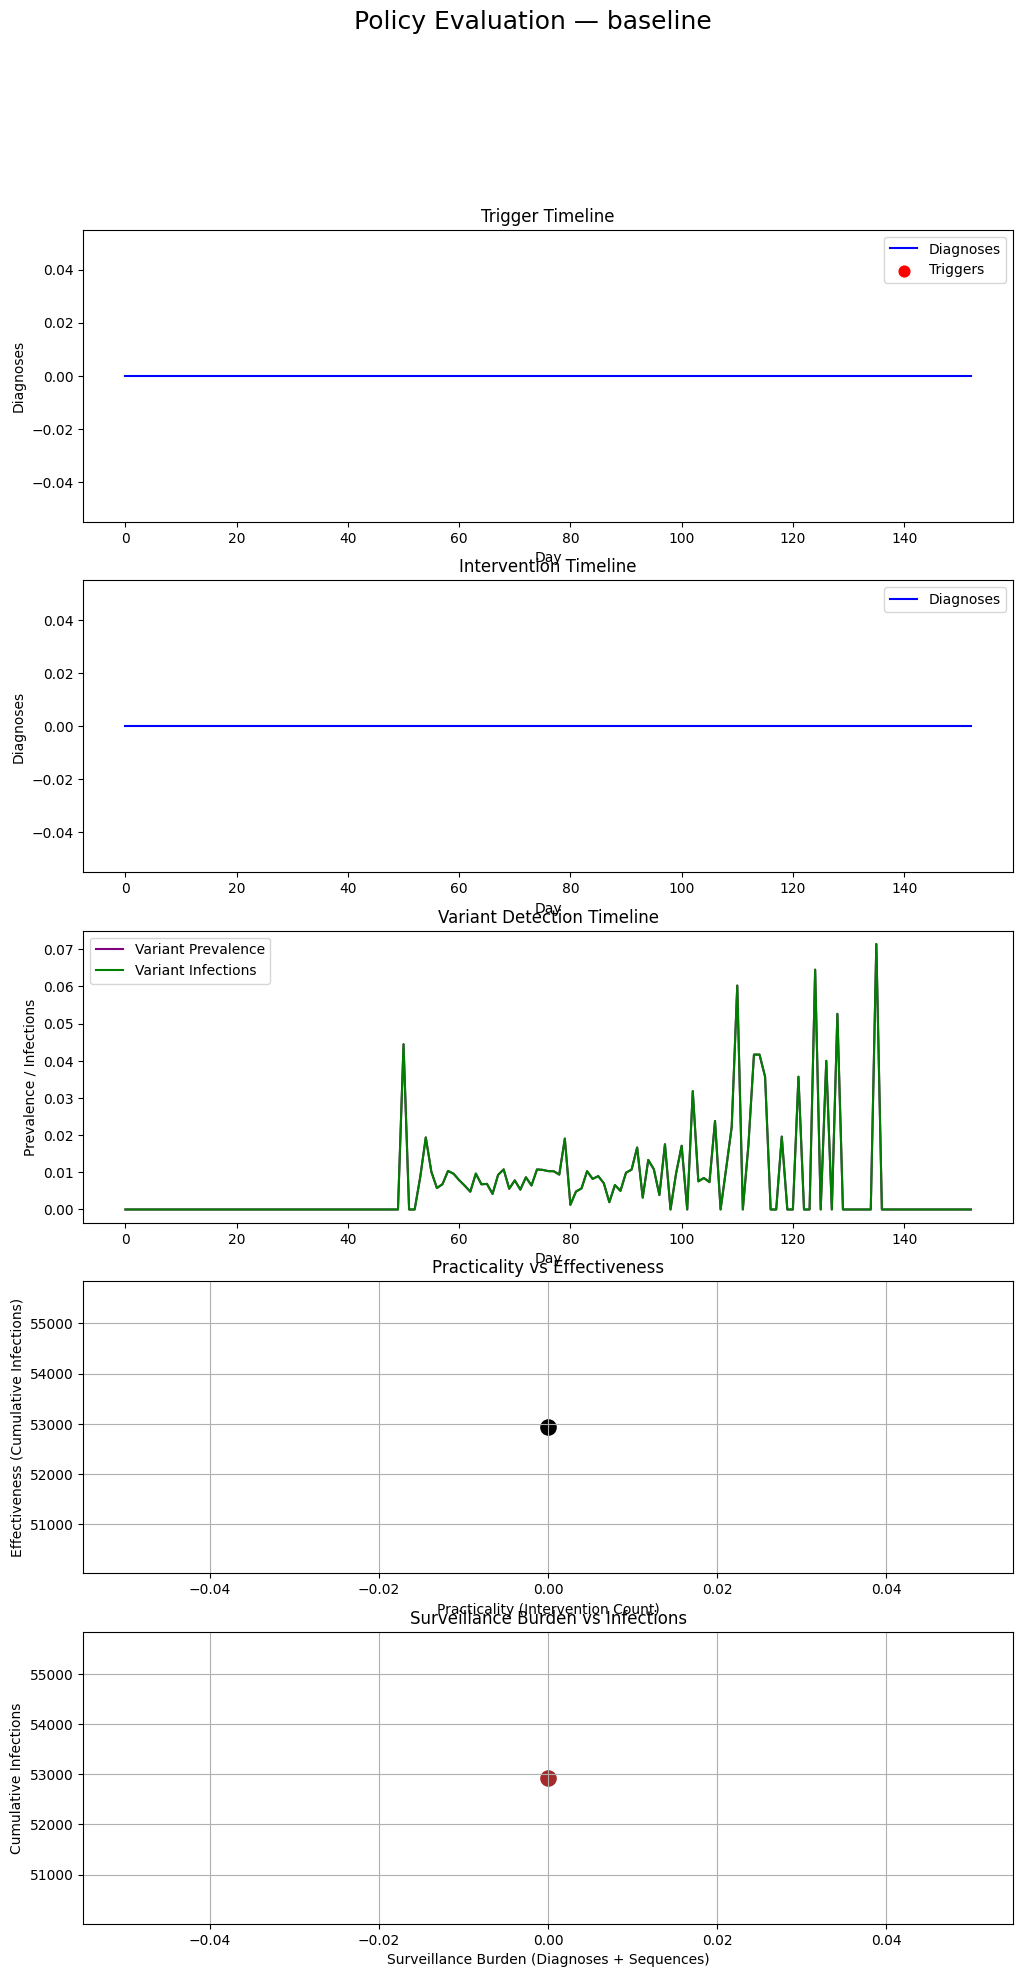

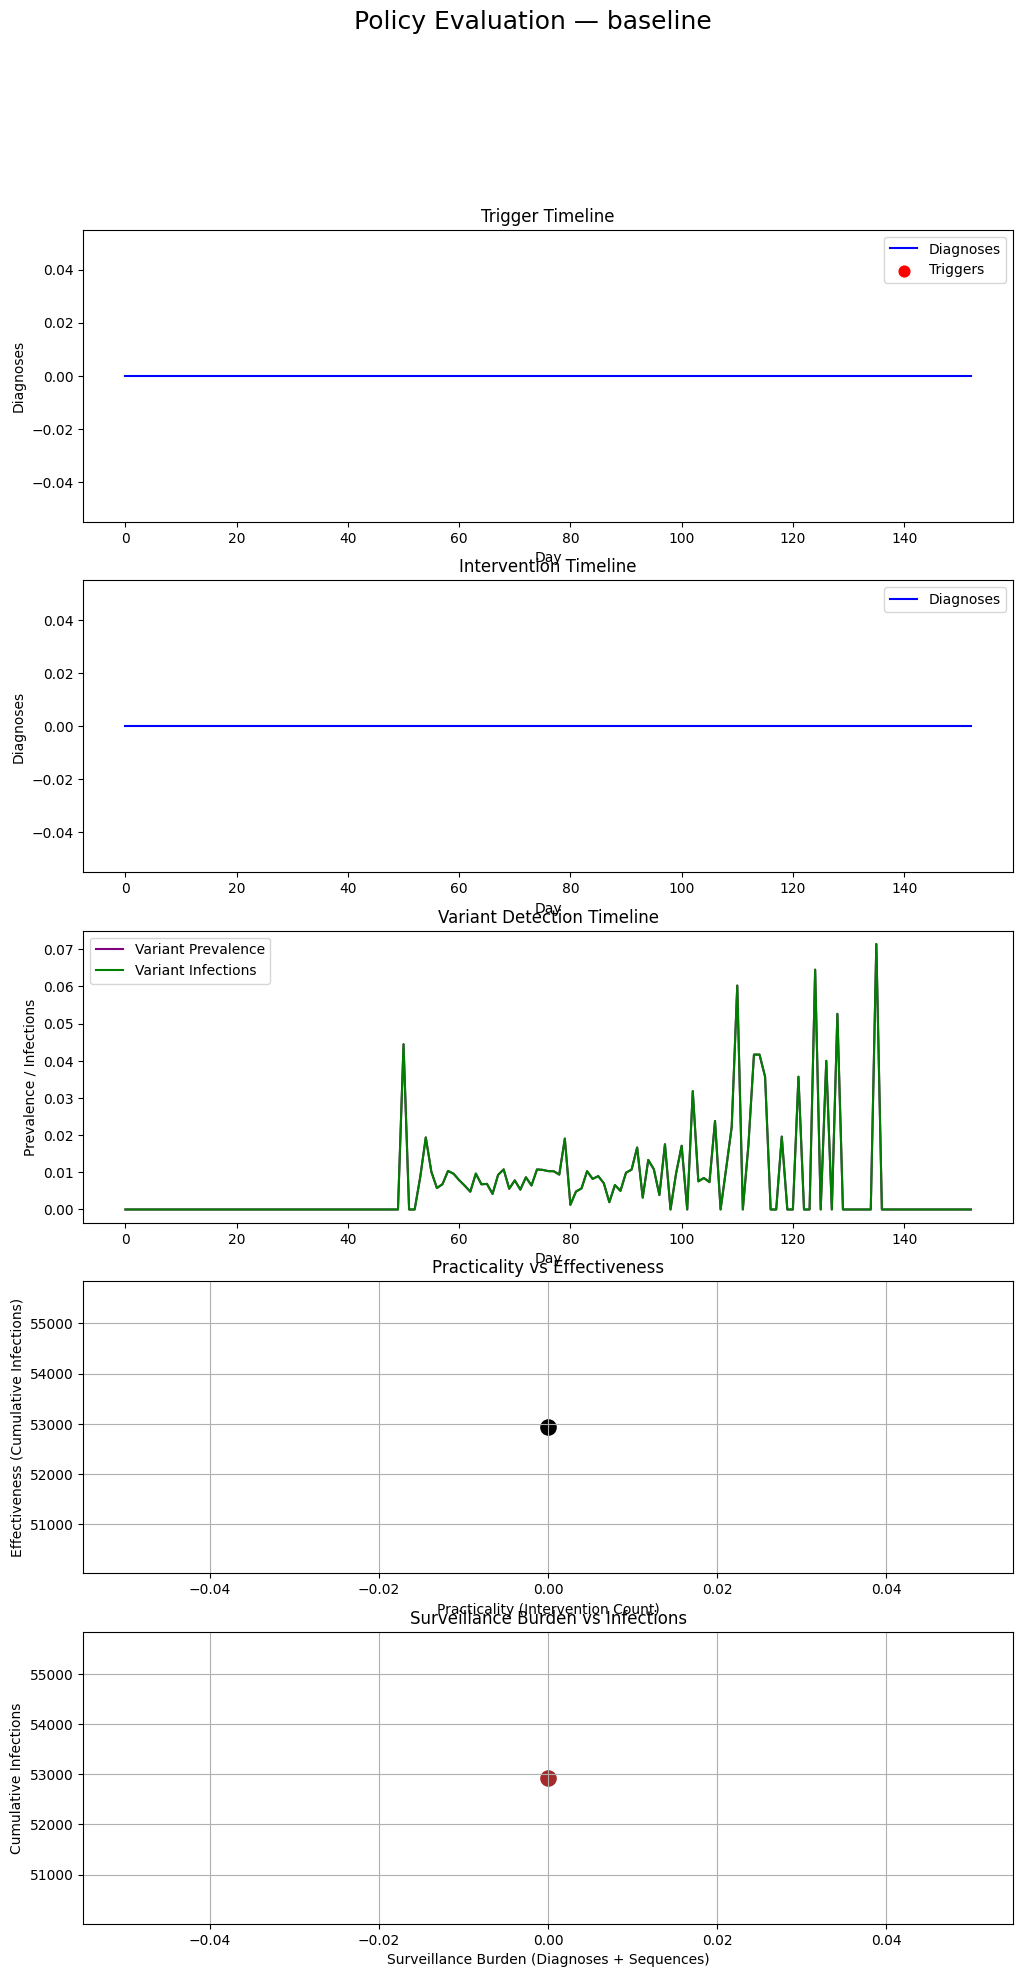

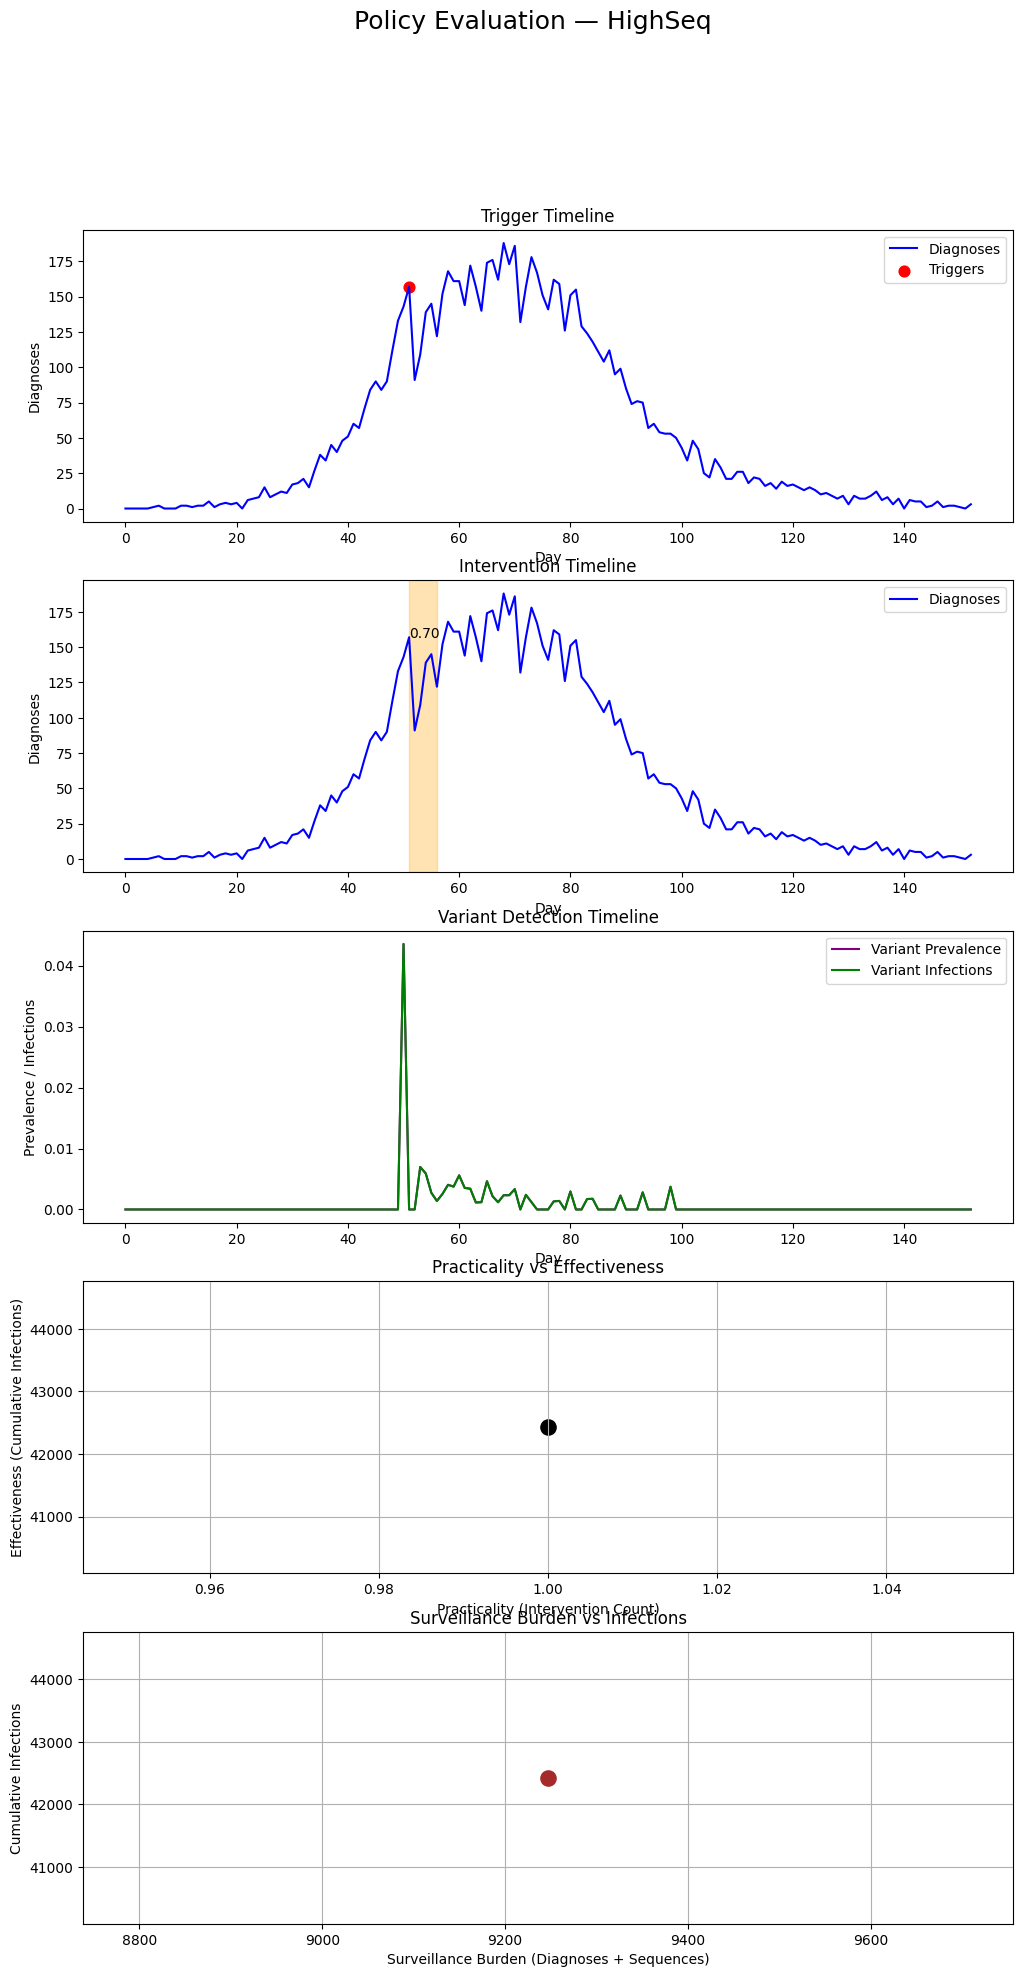

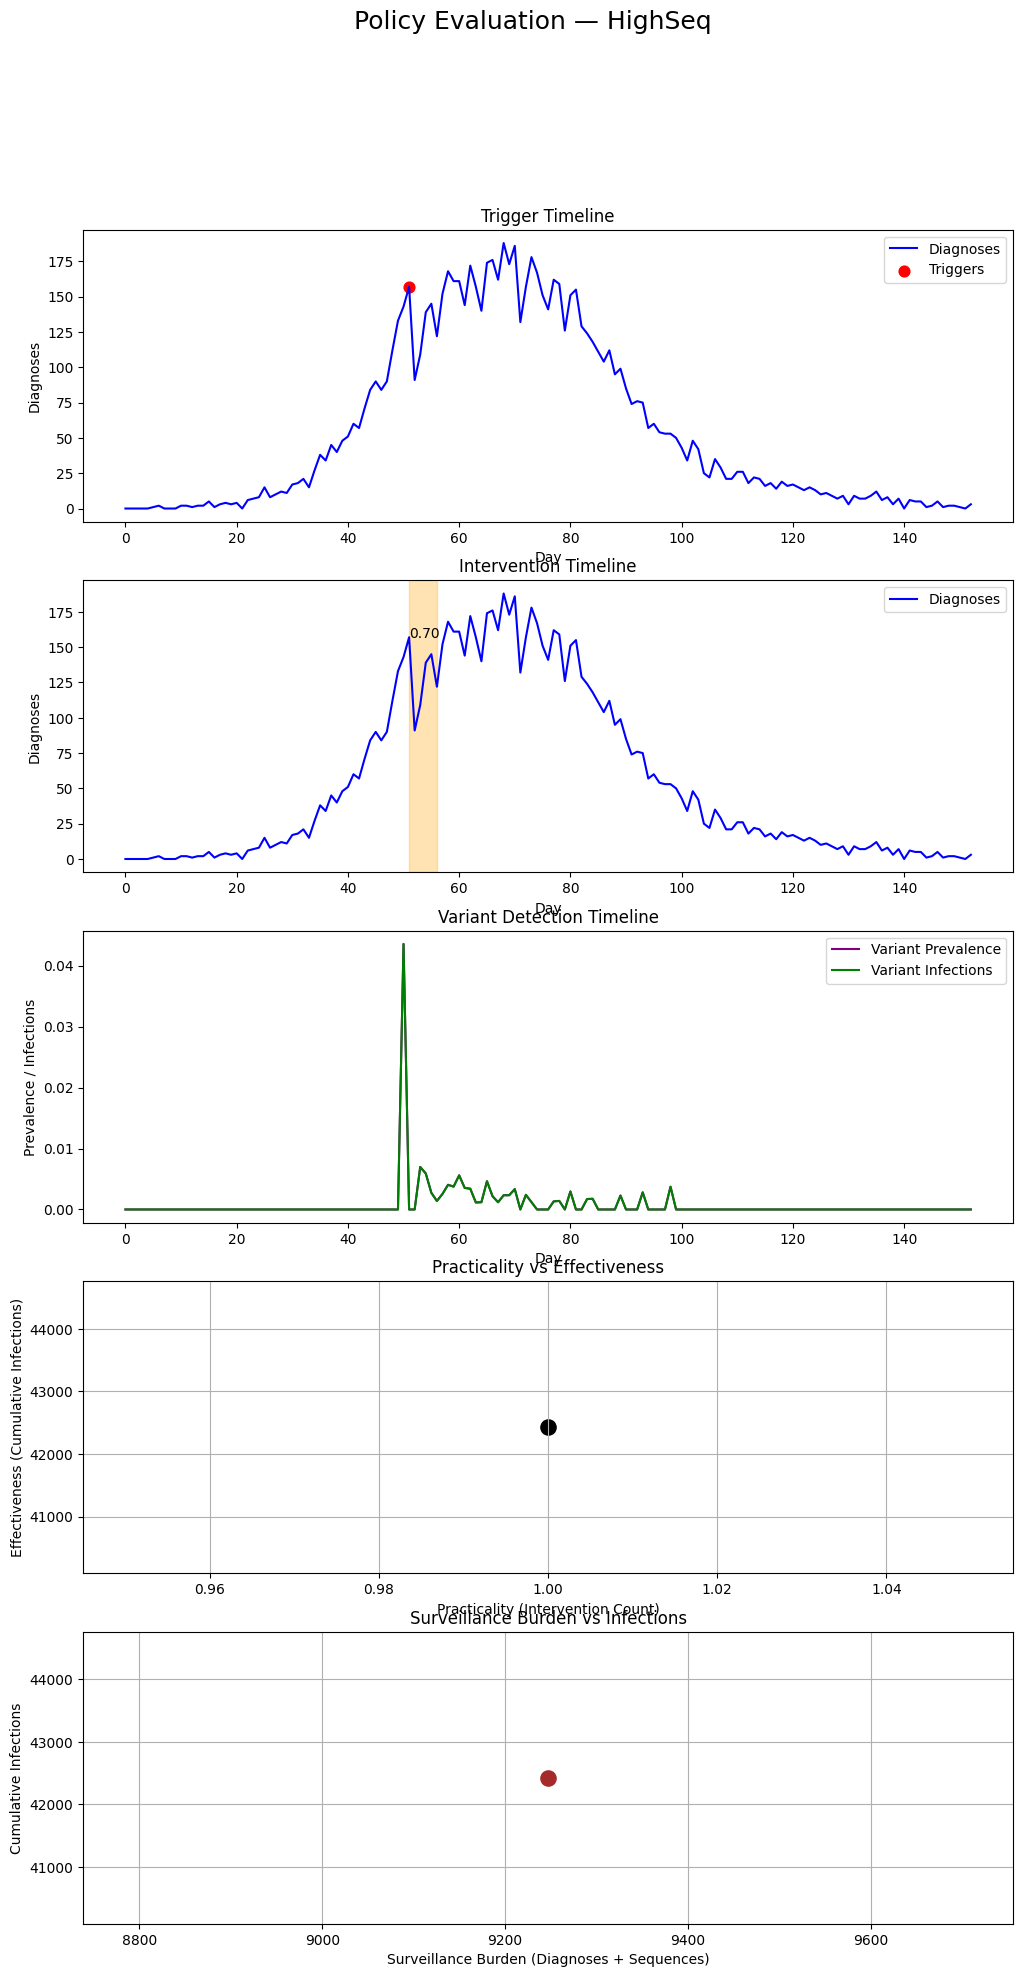

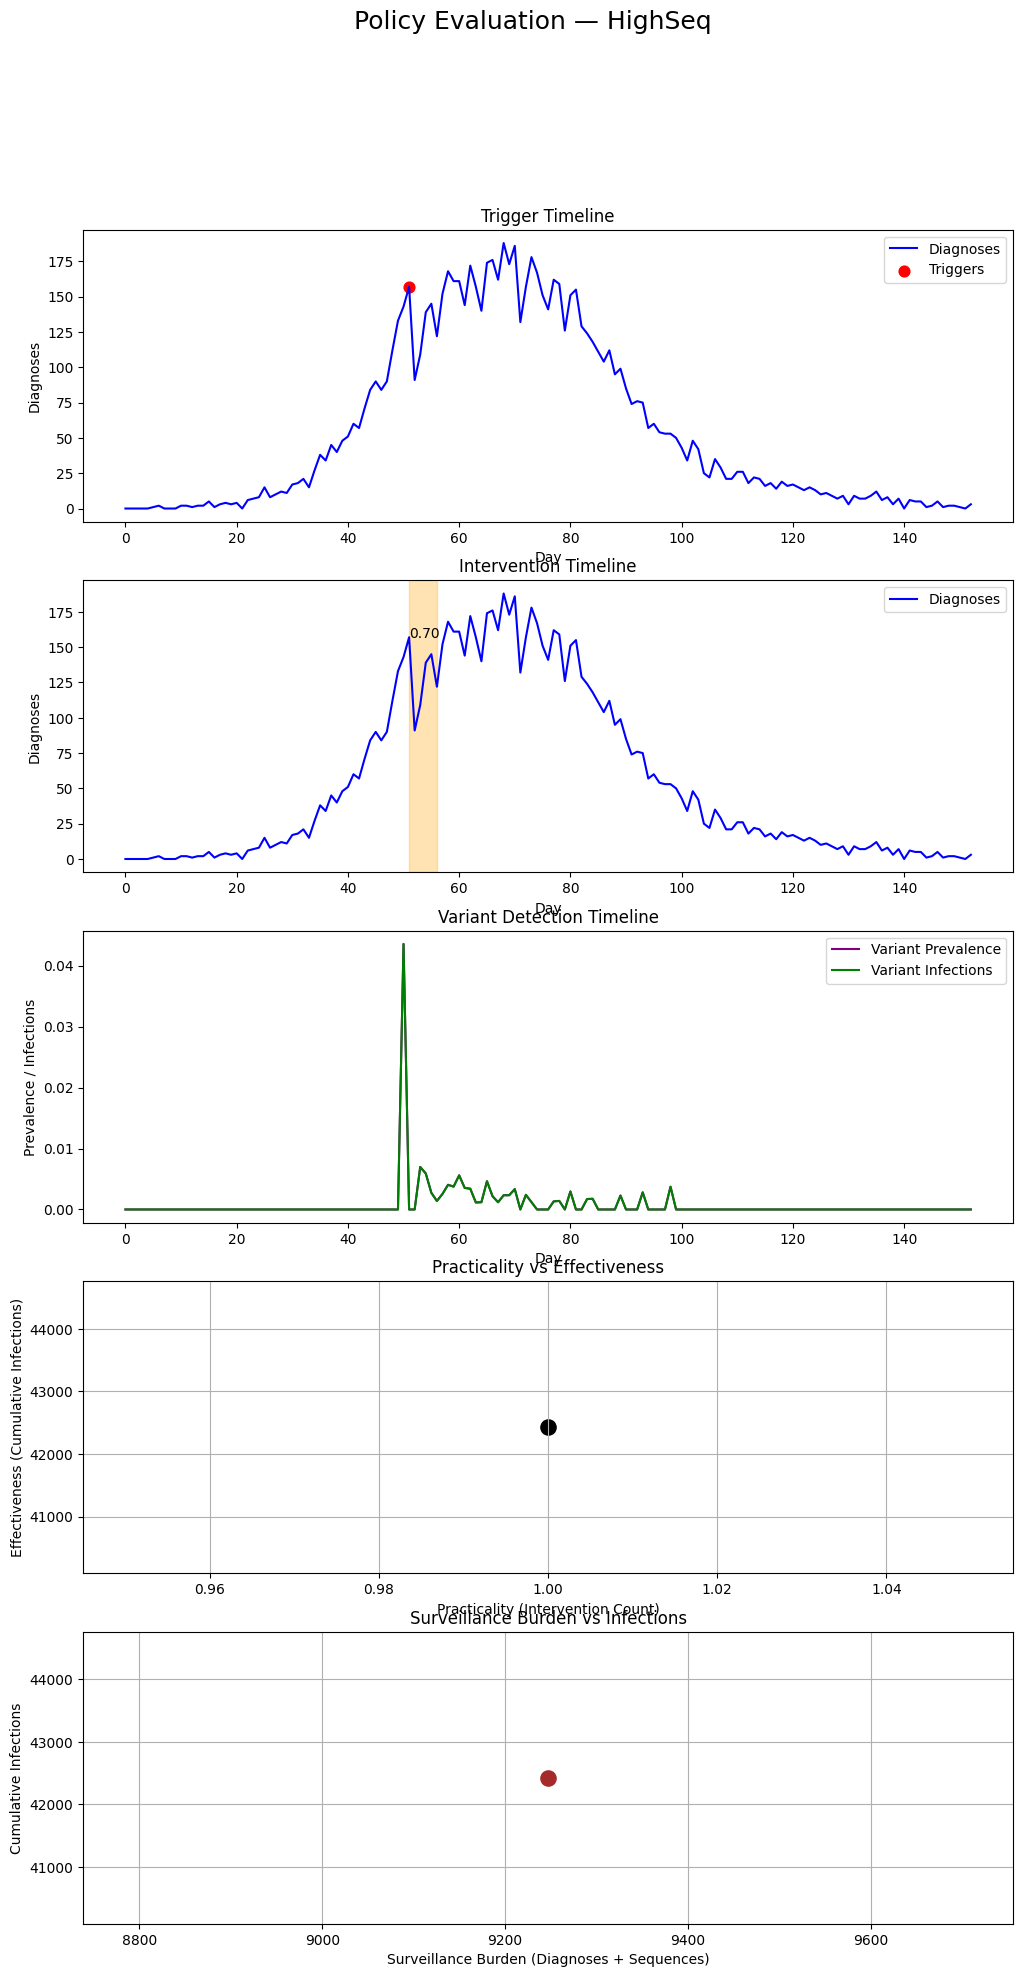

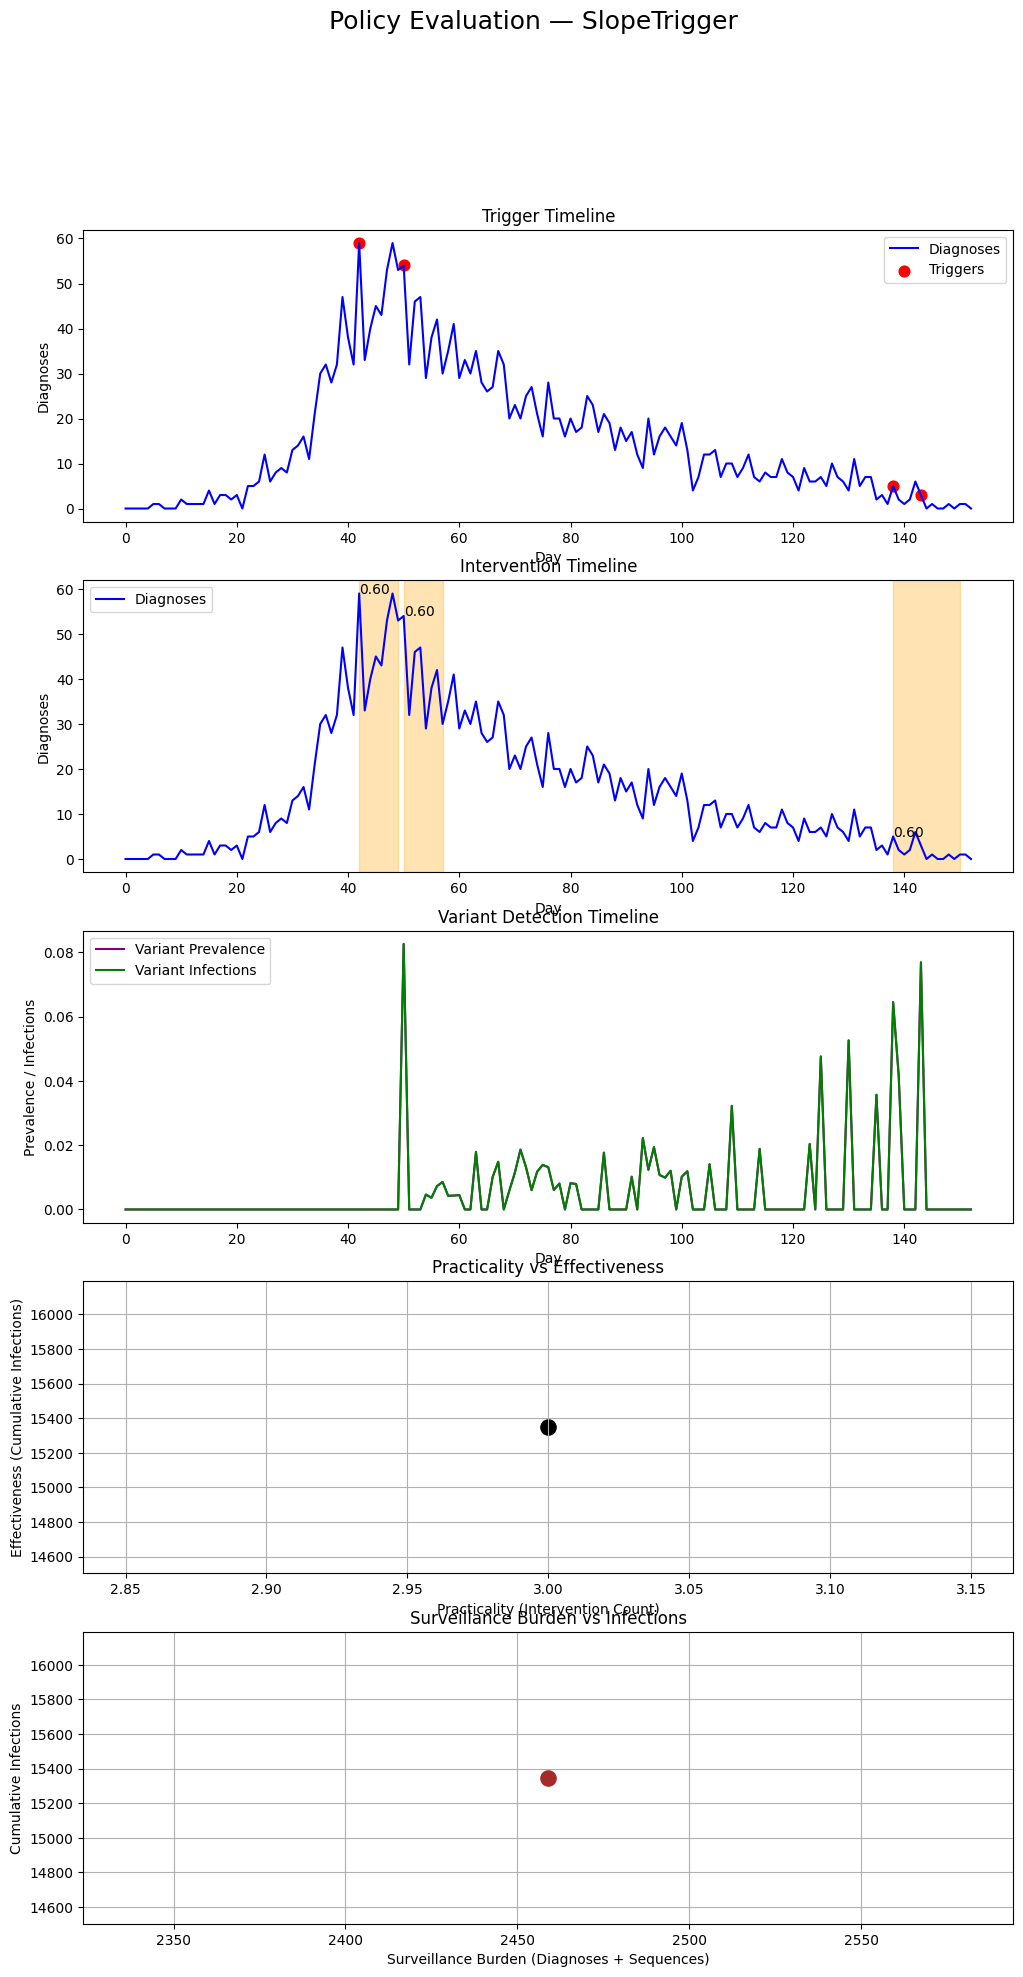

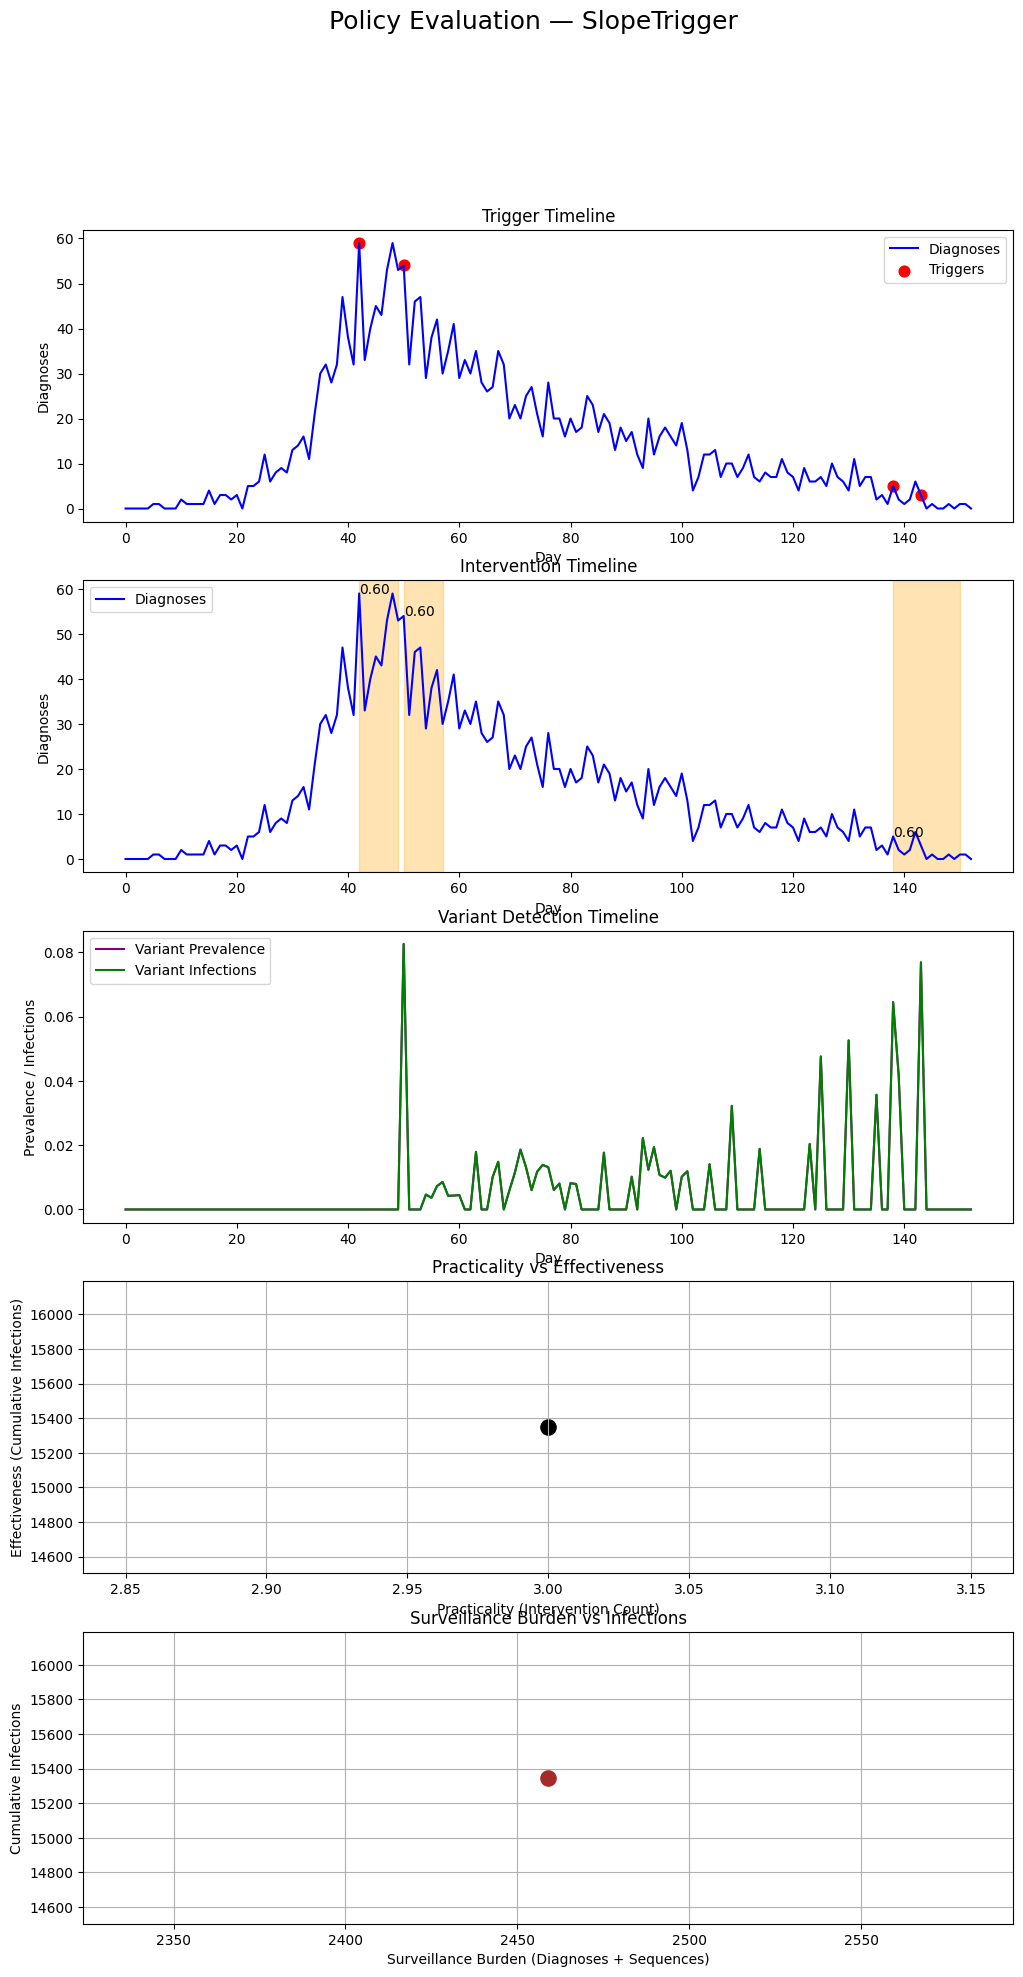

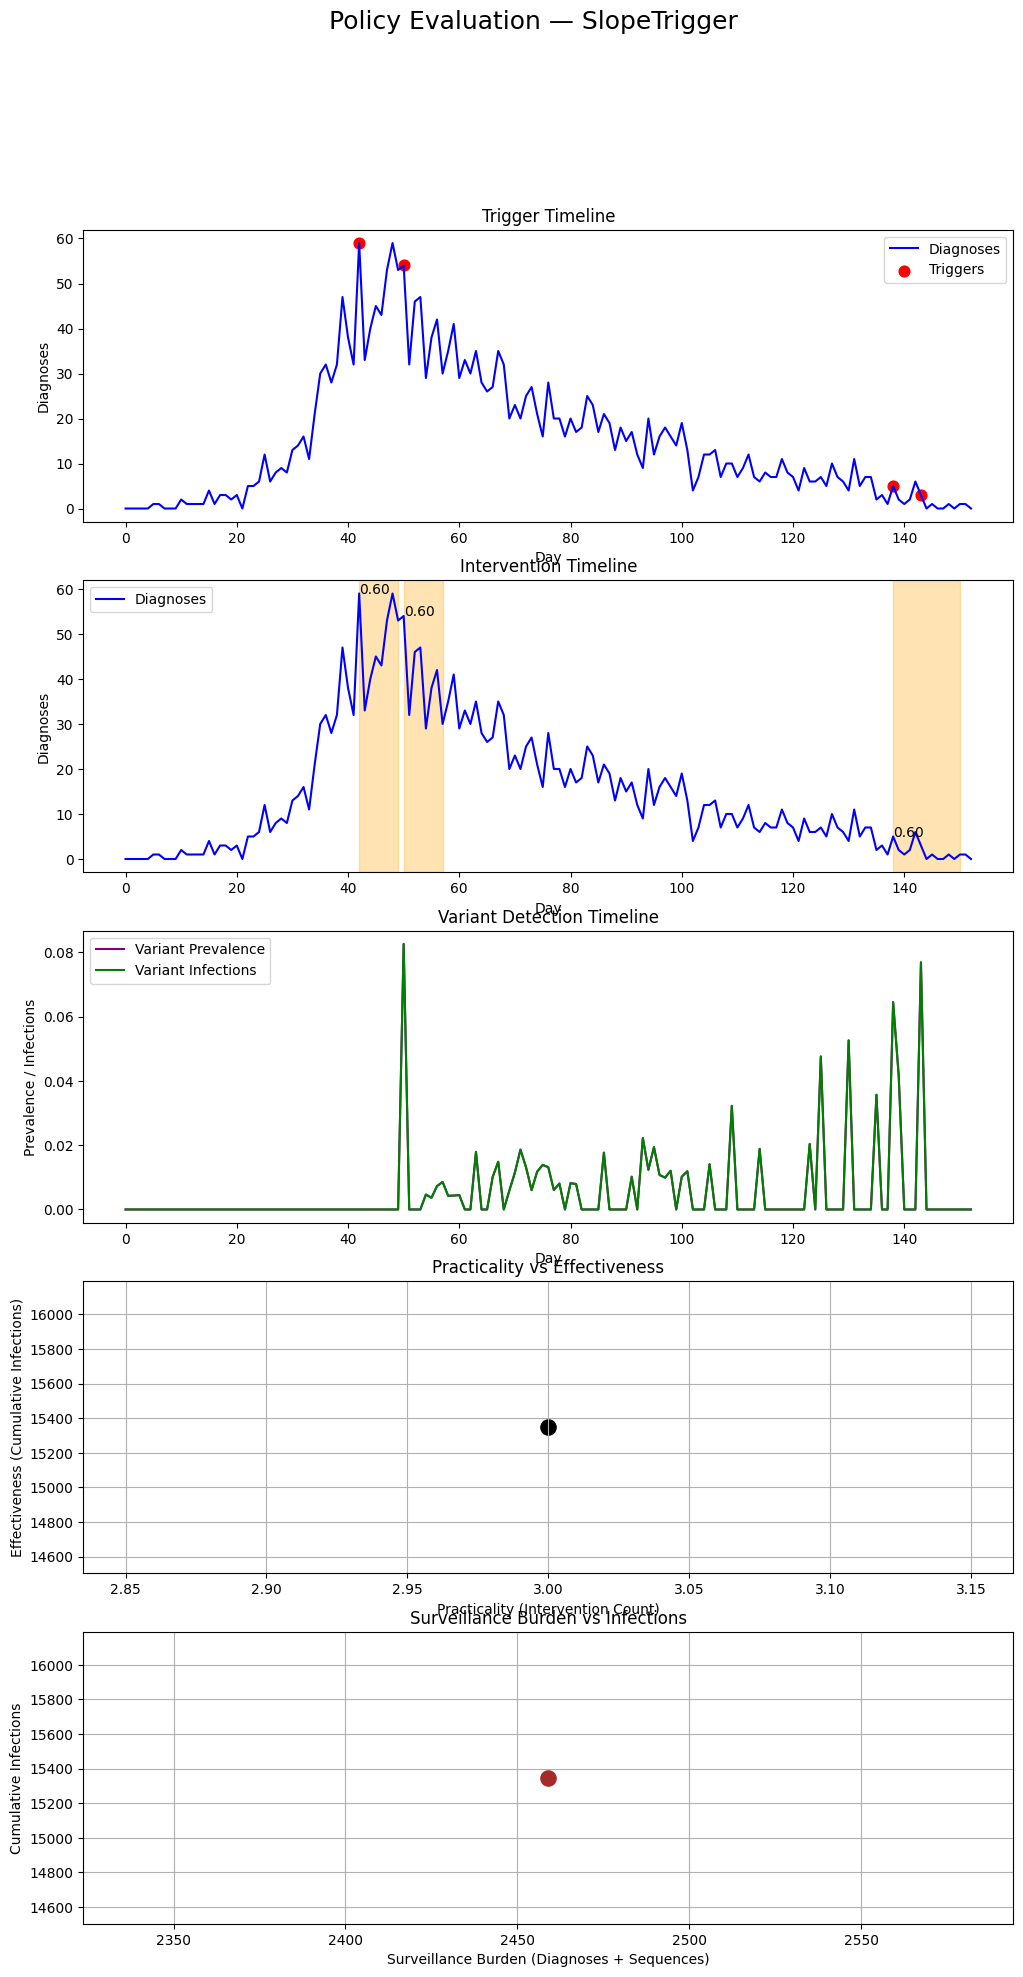

In [5]:
metrics = generate_policy_report(
    results_dict,
    outdir="policy_report_output",
    variant_intro_day=50
)


In [6]:
metrics


[{'name': 'baseline',
  'n_runs': 3,
  'mean_cum_inf': 52931.0,
  'mean_peak_inf': 1504.0,
  'mean_time_peak': 67.0,
  'mean_n_interventions': 0.0,
  'mean_avg_duration': 0.0,
  'mean_avg_intensity': 0.0,
  'mean_burden_diagnoses': 0.0,
  'mean_burden_sequences': 0.0,
  'mean_total_burden': 0.0,
  'mean_spread_speed': 0.0,
  'mean_detection_delay': None,
  'mean_prev_at_det': None},
 {'name': 'HighSeq',
  'n_runs': 3,
  'mean_cum_inf': 42428.0,
  'mean_peak_inf': 919.0,
  'mean_time_peak': 66.0,
  'mean_n_interventions': 1.0,
  'mean_avg_duration': 5.0,
  'mean_avg_intensity': 0.6999999999999998,
  'mean_burden_diagnoses': 8411.0,
  'mean_burden_sequences': 836.0,
  'mean_total_burden': 9247.0,
  'mean_spread_speed': 0.0,
  'mean_detection_delay': None,
  'mean_prev_at_det': None},
 {'name': 'SlopeTrigger',
  'n_runs': 3,
  'mean_cum_inf': 15348.0,
  'mean_peak_inf': 367.0,
  'mean_time_peak': 48.0,
  'mean_n_interventions': 3.0,
  'mean_avg_duration': 8.666666666666666,
  'mean_avg_in